# QSVT Compatibility and Synthesis Failure Cases

This tutorial separates three checks that are easy to conflate: extrema-based boundedness, structural single-sequence realizability, and numerical phase synthesis. It includes one successful odd polynomial, one bounded mixed-parity polynomial, and one polynomial whose narrow interior peak violates the QSVT bound.

Goals:

- certify boundedness by evaluating endpoints and derivative roots
- classify definite and mixed polynomial parity
- run PennyLane QSVT phase synthesis and retain reconstruction diagnostics
- interpret structured failures without overstating circuit execution

## Variable definitions

- $x\in[-1,1]$ is the normalized signal variable and $P(x)$ is a candidate polynomial.
- `coeffs` contains monomial coefficients in ascending degree order, so `coeffs[k]` multiplies $x^k$.
- `certificate` evaluates both interval endpoints and every numerically real derivative root.
- `max_abs_value` is $\max_{x\in[-1,1]}|P(x)|$ and `margin` is $1-\max|P(x)|$.
- `parity` is even when $P(-x)=P(x)$, odd when $P(-x)=-P(x)$, and mixed otherwise.
- `single_sequence_realizable` means one standard QSP/QSVT phase sequence satisfies the package's boundedness and parity checks.
- `angles` are PennyLane QSVT projector phases and `reconstruction_max_error` validates their scalar response.


## Truth contract

The notebook executes classical extrema certification and phase synthesis. It does not construct a problem-specific block encoding, run a QSVT circuit, prepare an application state, or perform hardware measurements. A failed synthesis report is diagnostic evidence, not an attempted device execution.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from notebooks._support import display_table
from qsvt.polynomials import eval_polynomial
from qsvt.stable import (
    certify_polynomial_boundedness,
    classify_polynomial_realizability,
    synthesize_phases,
)

np.set_printoptions(precision=6, suppress=True)


## Candidate polynomials

The odd cubic is comfortably bounded and should synthesize as one sequence. The affine polynomial is bounded but has mixed parity, so it needs separate even and odd sequences plus a combination mechanism. The quadratic has values below one on a coarse grid, but its derivative vanishes at $x=0.1$, where $P(0.1)=1.001$.


In [2]:
candidates = {
    "single-sequence odd cubic": np.array([0.0, 0.75, 0.0, -0.25]),
    "bounded mixed parity": np.array([0.25, 0.5]),
    "interior peak violation": np.array([0.996, 0.1, -0.5]),
}

diagnostics = {}
rows = []
for name, coeffs in candidates.items():
    certificate = certify_polynomial_boundedness(coeffs)
    realizability = classify_polynomial_realizability(coeffs)
    synthesis = synthesize_phases(
        coeffs,
        angle_solver="root-finding",
        reconstruction_num_points=129,
    )
    diagnostics[name] = {
        "certificate": certificate,
        "realizability": realizability,
        "synthesis": synthesis,
    }
    rows.append(
        {
            "case": name,
            "degree": realizability.degree,
            "parity": realizability.parity,
            "max_abs": certificate.max_abs_value,
            "margin": certificate.margin,
            "kind": realizability.kind,
            "synthesized": synthesis.succeeded,
        }
    )

display_table(
    "Compatibility and synthesis diagnostics",
    rows,
    [
        ("case", lambda row: row["case"]),
        ("degree", lambda row: row["degree"]),
        ("parity", lambda row: row["parity"]),
        ("max |P|", lambda row: row["max_abs"]),
        ("margin", lambda row: row["margin"]),
        ("realizability", lambda row: row["kind"]),
        ("synthesized", lambda row: row["synthesized"]),
    ],
    layout="rows",
)


Compatibility and synthesis diagnostics
---------------------------------------
case                       degree  parity  max |P|  margin  realizability                     synthesized
-------------------------  ------  ------  -------  ------  --------------------------------  -----------
single-sequence odd cubic  3       odd     0.5      0.5     single-sequence-qsp-qsvt          True       
bounded mixed parity       1       mixed   0.75     0.25    multiple-parity-sequences-or-lcu  False      
interior peak violation    2       mixed   1.001    -0.001  classical-polynomial-only         False      


## Why extrema certification matters

A sampled grid is useful for visualization but is not a certificate. The nine-point grid below misses the violating peak because it does not contain $x=0.1$. The extrema calculation finds that point from the derivative and records the negative boundedness margin.


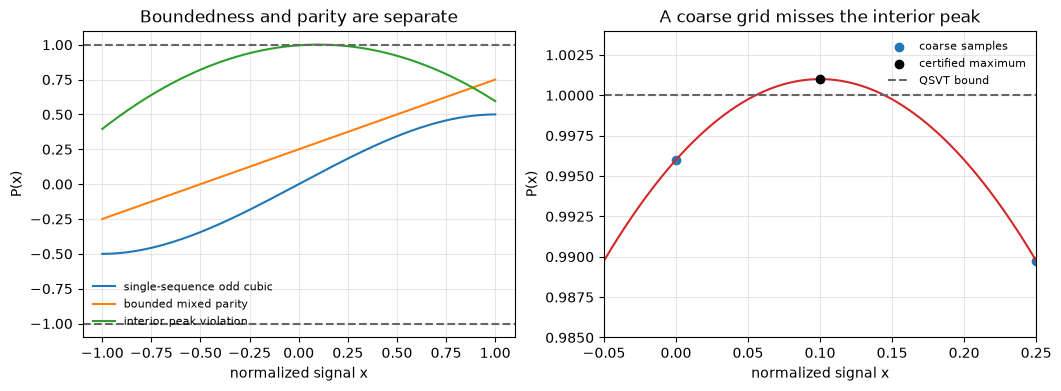

coarse-grid max |P|: 0.996000
certified max |P|: 1.001000
maximizing point: 0.100000


In [3]:
peak_coeffs = candidates["interior peak violation"]
coarse_xs = np.linspace(-1.0, 1.0, 9)
coarse_max = float(np.max(np.abs(eval_polynomial(peak_coeffs, coarse_xs))))
peak_certificate = diagnostics["interior peak violation"]["certificate"]

xs = np.linspace(-1.0, 1.0, 2001)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), constrained_layout=True)
for name, coeffs in candidates.items():
    axes[0].plot(xs, eval_polynomial(coeffs, xs), label=name)
axes[0].axhline(1.0, color="0.4", linestyle="--")
axes[0].axhline(-1.0, color="0.4", linestyle="--")
axes[0].set_xlabel("normalized signal x")
axes[0].set_ylabel("P(x)")
axes[0].set_title("Boundedness and parity are separate")
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=0.3)

zoom_xs = np.linspace(-0.05, 0.25, 601)
axes[1].plot(zoom_xs, eval_polynomial(peak_coeffs, zoom_xs), color="tab:red")
axes[1].scatter(coarse_xs, eval_polynomial(peak_coeffs, coarse_xs), color="tab:blue", label="coarse samples")
axes[1].scatter([peak_certificate.maximizing_point], [peak_certificate.max_abs_value], color="black", zorder=3, label="certified maximum")
axes[1].axhline(1.0, color="0.4", linestyle="--", label="QSVT bound")
axes[1].set_xlim(-0.05, 0.25)
axes[1].set_ylim(0.985, 1.004)
axes[1].set_xlabel("normalized signal x")
axes[1].set_ylabel("P(x)")
axes[1].set_title("A coarse grid misses the interior peak")
axes[1].legend(fontsize=8, frameon=False)
axes[1].grid(alpha=0.3)
plt.show()

print(f"coarse-grid max |P|: {coarse_max:.6f}")
print(f"certified max |P|: {peak_certificate.max_abs_value:.6f}")
print(f"maximizing point: {peak_certificate.maximizing_point:.6f}")


## Phase convention, reconstruction, and structured failures

The successful result records PennyLane's QSVT projector-phase convention and validates the synthesized sequence on 129 scalar signal values. The other cases fail before numerical angle solving: mixed parity requires an additional combination construction, while the interior peak violates the unit bound.


In [4]:
success = diagnostics["single-sequence odd cubic"]["synthesis"]
failure_rows = []
for name in ["bounded mixed parity", "interior peak violation"]:
    result = diagnostics[name]["synthesis"]
    failure_rows.append(
        {
            "case": name,
            "error_type": result.error_type,
            "reason": result.error,
        }
    )

print(f"phase count: {success.angles.size}")
print(f"phase convention: {success.convention}")
print(f"reconstruction max error: {success.reconstruction_max_error:.3e}")
display_table(
    "Structured failures",
    failure_rows,
    [
        ("case", lambda row: row["case"]),
        ("error type", lambda row: row["error_type"]),
        ("reason", lambda row: row["reason"]),
    ],
    layout="rows",
)


phase count: 4
phase convention: PennyLane QSVT projector-phase convention; polynomial coefficients are in ascending monomial order.
reconstruction max error: 5.000e-13
Structured failures
-------------------
case                     error type                    reason                                                                                                                                                              
-----------------------  ----------------------------  --------------------------------------------------------------------------------------------------------------------------------------------------------------------
bounded mixed parity     PolynomialRealizabilityError  The polynomial is extrema-bounded but has mixed parity. Realize its even and odd components separately and combine them, for example with an LCU-style construction.
interior peak violation  PolynomialRealizabilityError  The polynomial can be evaluated classically but is not bounded by one on the

## Validation

These checks protect the intended distinction between boundedness, parity, structural realizability, and numerical synthesis. They also ensure the interior extremum remains a case that sampled inspection can miss.


In [5]:
odd = diagnostics["single-sequence odd cubic"]
mixed = diagnostics["bounded mixed parity"]
peak = diagnostics["interior peak violation"]

assert odd["realizability"].single_sequence_realizable
assert odd["synthesis"].succeeded
assert odd["synthesis"].reconstruction_max_error < 1e-9
assert mixed["certificate"].is_bounded
assert mixed["realizability"].requires_parity_decomposition
assert not mixed["synthesis"].succeeded
assert coarse_max < 1.0
assert not peak["certificate"].is_bounded
assert np.isclose(peak["certificate"].maximizing_point, 0.1)
assert not peak["synthesis"].succeeded
print("validation: passed")


validation: passed
